In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml, load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import normalize

In [31]:
iris_dataset = load_iris(as_frame=True)
iris_data = iris_dataset["data"]
target = iris_dataset["target"]
class_names = iris_dataset["target_names"]
feature_names = iris_dataset["feature_names"]

In [162]:
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto")

In [163]:
kmeans.fit(iris_data)
cluster_centres = {}
for a,b in [(x,y) for x,y in zip(feature_names, kmeans.cluster_centers_.T)]:
    cluster_centres[a] = b
cluster_labels = kmeans.labels_
nclusters = np.max(cluster_labels)+1
clusterwidth = (nclusters-1)/nclusters
sorted_data=iris_data
sorted_data["cluster"] = cluster_labels
sorted_data["target"] = target

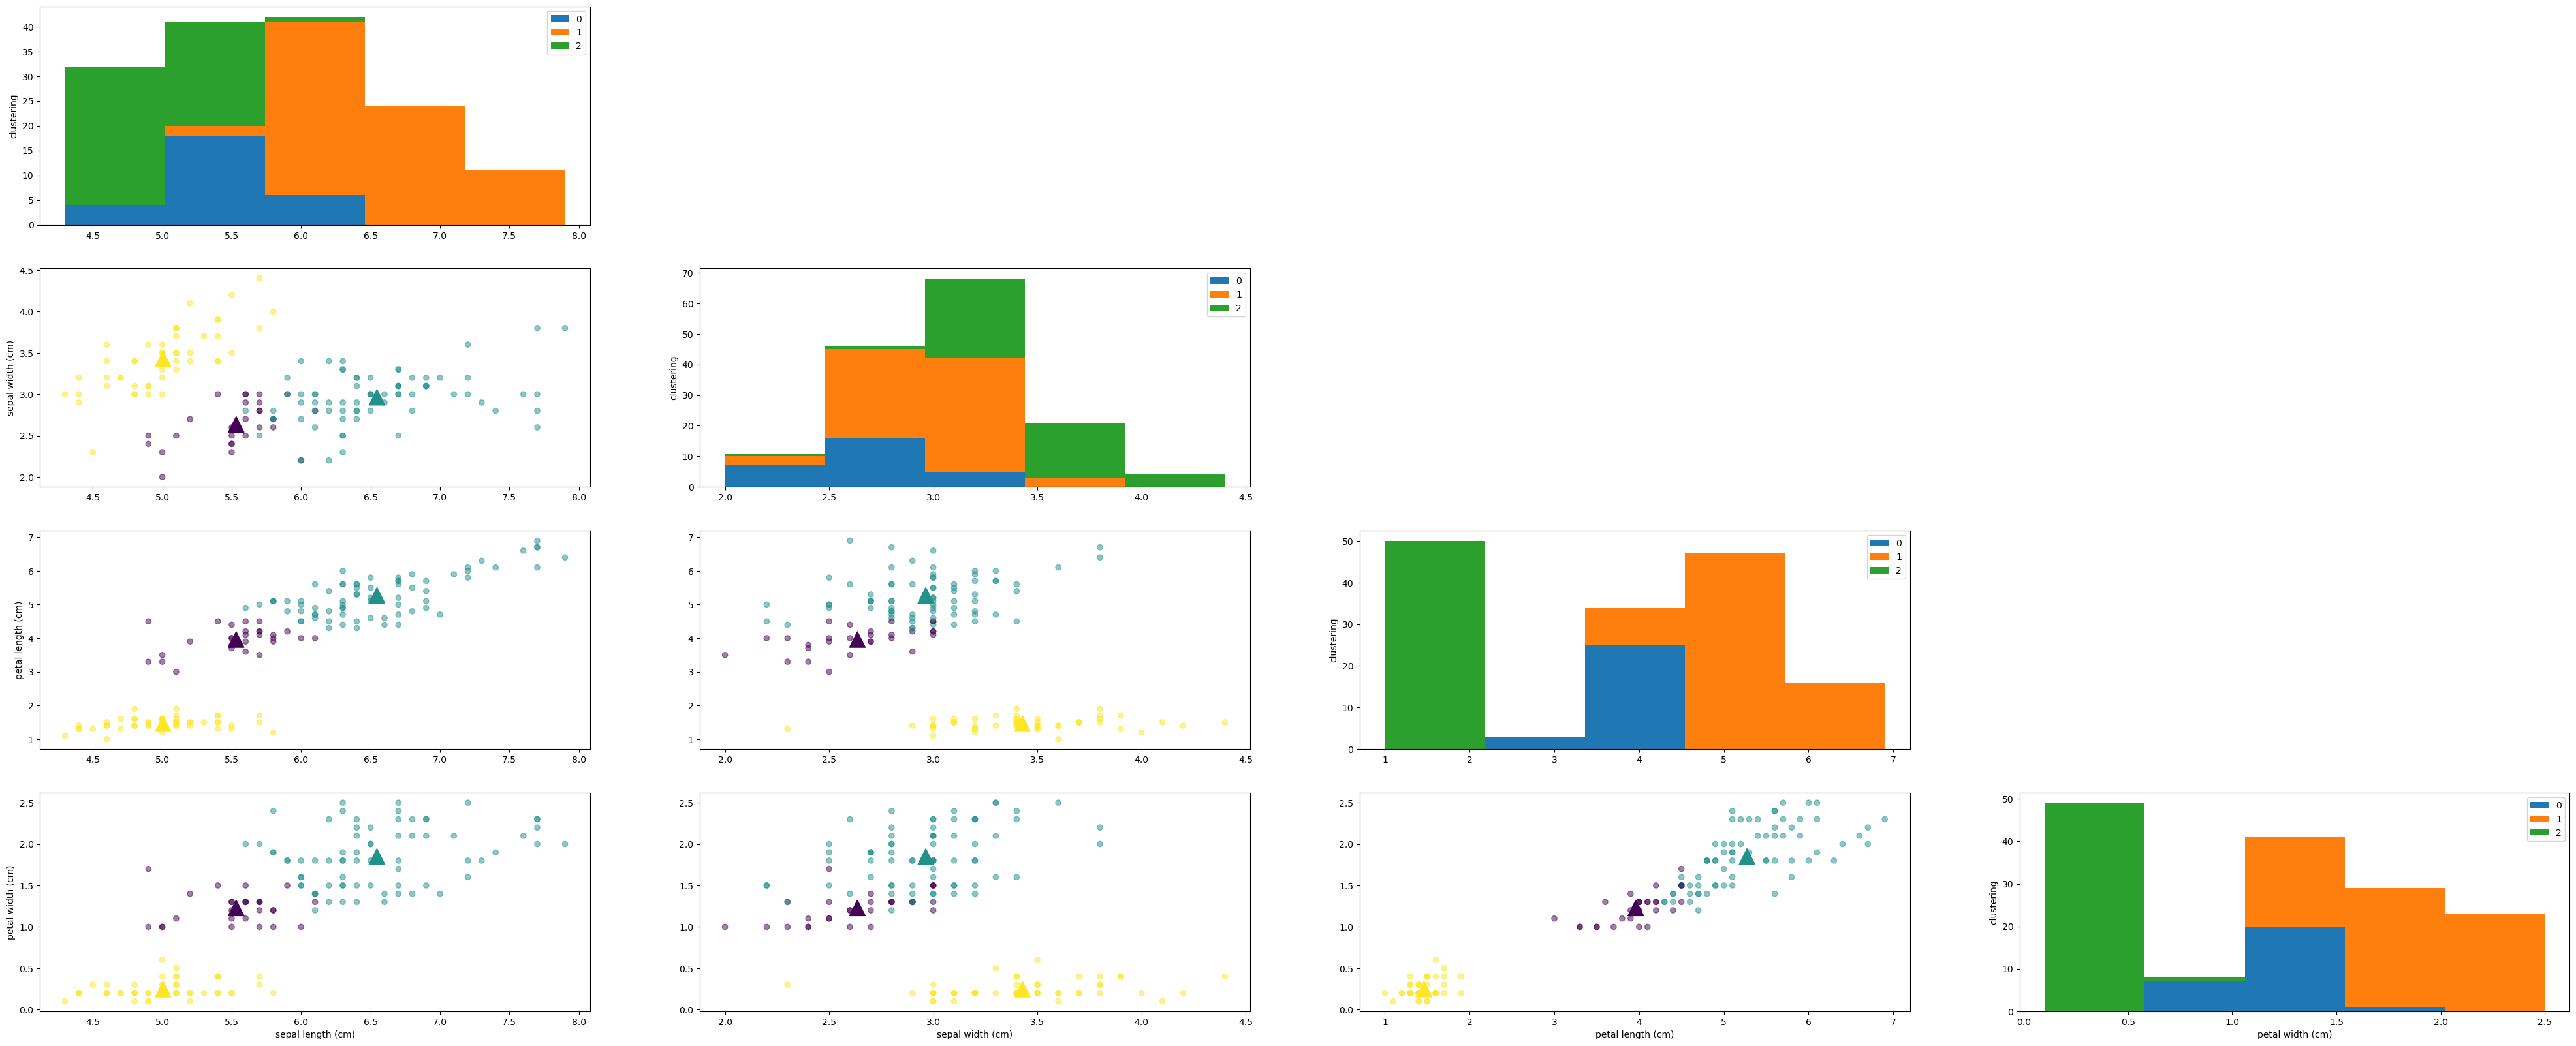

In [164]:
fig, axs = plt.subplots(
    len(feature_names), len(feature_names), figsize=(50,20))

axs = axs.T
for x in range(len(feature_names)):
    x_label = feature_names[x]
    axs[x,-1].set_xlabel(x_label)
    for y in range(len(feature_names)):
        if x<y:
            y_label = feature_names[y]
            axs[x,y].scatter(iris_data[x_label][:], iris_data[y_label][:], c=sorted_data["cluster"], alpha=0.5)
            if x_label in iris_data and y_label in iris_data:
                axs[x,y].scatter(cluster_centres[x_label], cluster_centres[y_label], marker="^", c=range(0, nclusters), s=300)
            axs[0,y].set_ylabel(y_label)
        elif x==y:
            plotData = [sorted_data.loc[(sorted_data["cluster"]==c)][x_label] for c in range(0, nclusters)]
            axs[x,y].hist(plotData, bins=nbins, stacked=True, label=range(0, nclusters))
            axs[x,y].set_ylabel("clustering")
            axs[x,y].legend()
        else:
            axs[x,y].set_visible(False)
plt.show()

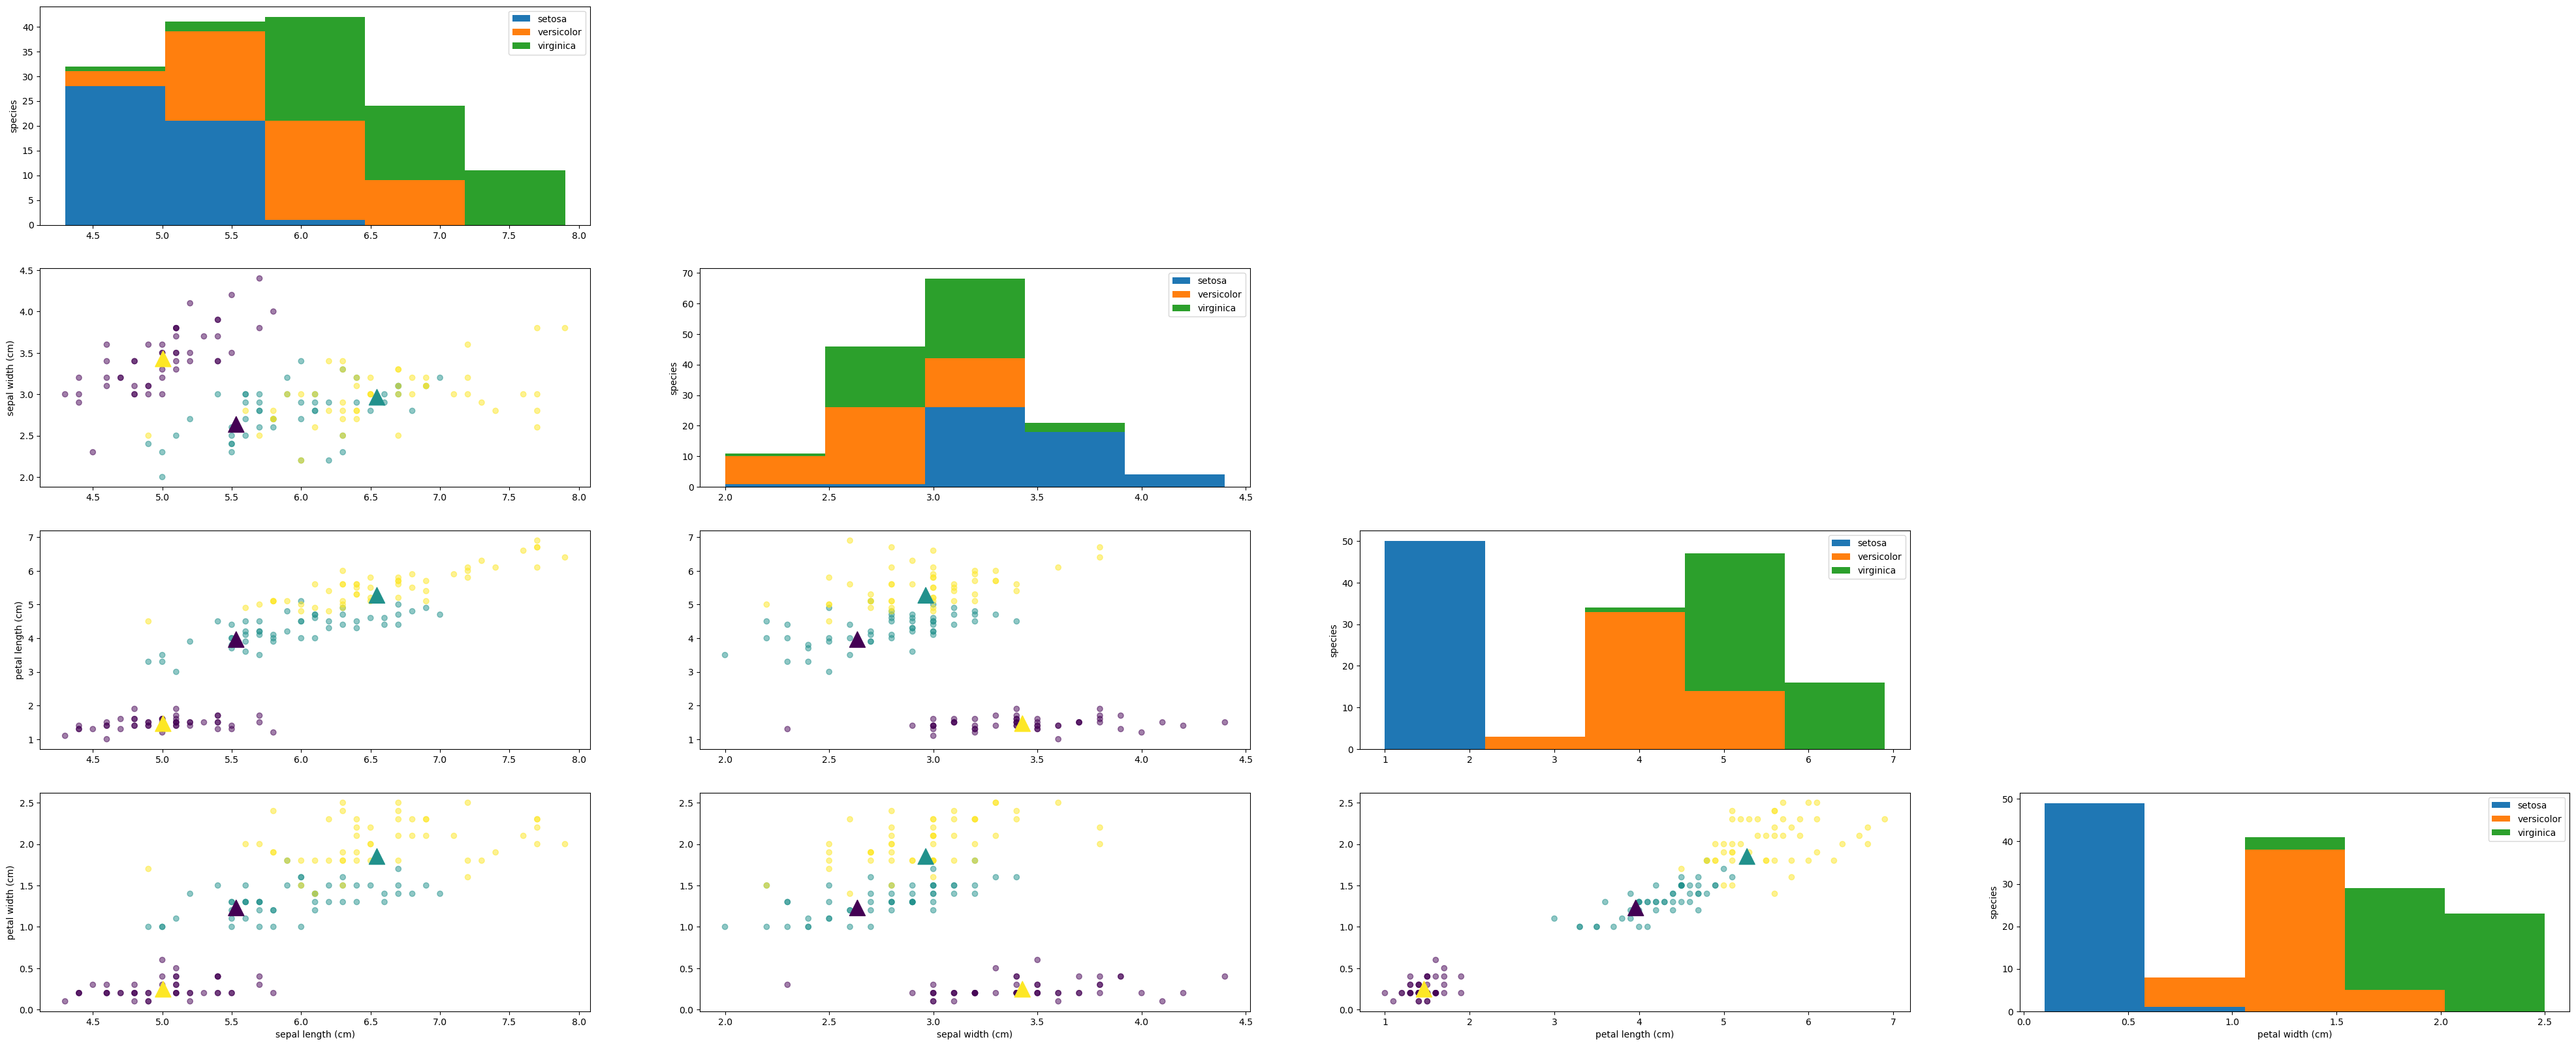

In [165]:
fig, axs = plt.subplots(
    len(feature_names), len(feature_names), figsize=(50,20))

axs = axs.T
for x in range(len(feature_names)):
    x_label = feature_names[x]
    axs[x,-1].set_xlabel(x_label)
    for y in range(len(feature_names)):
        if x<y:
            y_label = feature_names[y]
            axs[x,y].scatter(iris_data[x_label][:], iris_data[y_label][:], c=sorted_data["target"], alpha=0.5)
            if x_label in iris_data and y_label in iris_data:
                axs[x,y].scatter(cluster_centres[x_label], cluster_centres[y_label], marker="^", c=range(0, nclusters), s=300)
            axs[0,y].set_ylabel(y_label)
        elif x==y:
            plotData = [sorted_data.loc[(sorted_data["target"]==c)][x_label] for c in range(0, nclusters)]
            axs[x,y].hist(plotData, bins=nbins, stacked=True, label=class_names)
            axs[x,y].set_ylabel("species")
            axs[x,y].legend()
        else:
            axs[x,y].set_visible(False)
plt.show()

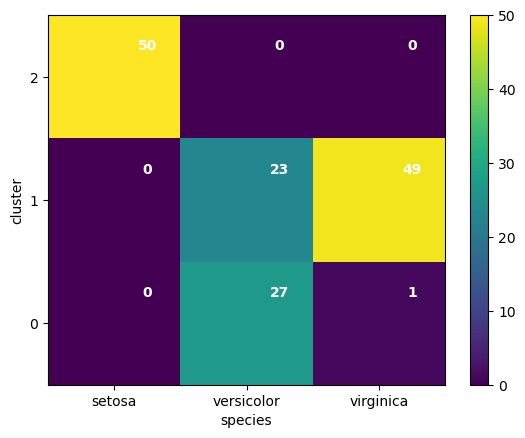

In [172]:
#raw 2d plotting of clustering vs species
fig, ax = plt.subplots(1,1)

hist, xbins, ybins, im = ax.hist2d(sorted_data["target"], sorted_data["cluster"], bins=(3,nclusters))
ax.set_xticks(np.arange(2/6, 2, 2/3), labels=class_names)
ax.set_yticks(np.arange((nclusters-1)/(2*nclusters), nclusters-1, (nclusters-1)/nclusters), labels=np.arange(0, nclusters, 1))

ax.set_xlabel("species")
ax.set_ylabel("cluster")

fig.colorbar(im)
for i in range(len(xbins)-1):
    for j in range(len(ybins)-1):
        ax.text(xbins[j]+0.5,ybins[i]+0.5, "%0.f" %hist.T[i,j], 
                color="w", ha="center", va="center", fontweight="bold")

plt.show()

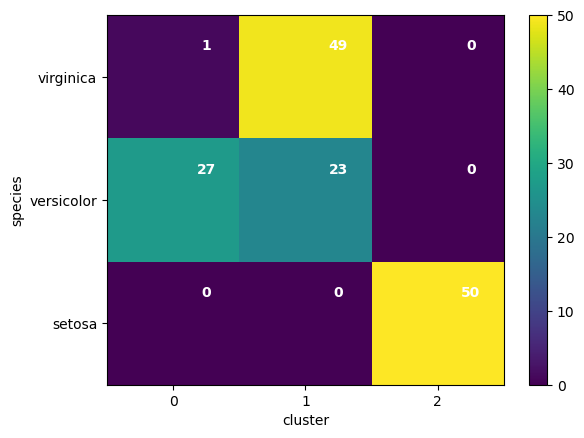

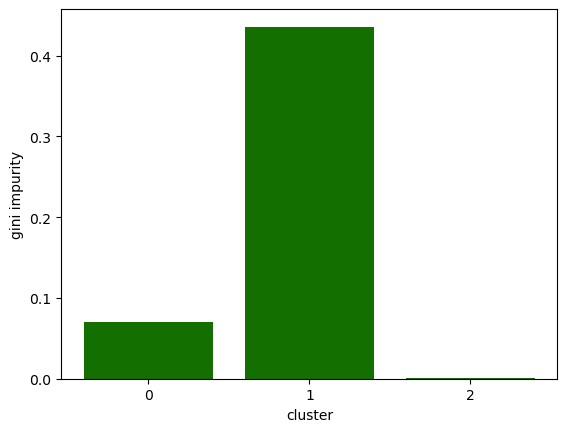

In [175]:
fig, ax = plt.subplots(1,1)

hist, xbins, ybins, im = ax.hist2d(sorted_data["cluster"], sorted_data["target"], bins=(3,nclusters))
ax.set_yticks(np.arange(2/6, 2, 2/3), labels=class_names)
ax.set_xticks(np.arange((nclusters-1)/(2*nclusters), nclusters-1, (nclusters-1)/nclusters), labels=np.arange(0, nclusters, 1))

ax.set_xlabel("cluster")
ax.set_ylabel("species")

fig.colorbar(im)
gini_impurity = [0., 0., 0.]
for i in range(len(xbins)-1):
    n_in_clust = sum(hist[i])
    gini = 1.001
    for j in range(len(ybins)-1):
        gini -= (hist[i,j]/n_in_clust)**2
        ax.text(xbins[j]+0.5,ybins[i]+0.5, "%0.f" %hist.T[i,j], 
                color="w", ha="center", va="center", fontweight="bold")
    gini_impurity[i] = gini
        
plt.show()

fig, ax = plt.subplots(1,1)
ax.bar(np.arange(0, nclusters, 1), gini_impurity, width=0.8, align="center", color=gini_impurity)
ax.set_xlabel("cluster")
ax.set_xticks(np.arange(0, nclusters, 1), labels=np.arange(0, nclusters, 1))
ax.set_ylabel("gini impurity")
plt.show()

In [177]:
hist[0,1]

27.0